### import needed packages and read the combined dataset

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
import re
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

In [19]:
# Load the unified email dataset
email_df = pd.read_csv('datasets/processed/combined_dataset.csv')

print(f"Total Records: {email_df.shape[0]:,}")
print(f"Total Features: {email_df.shape[1]}")
print(f"Memory Usage: {email_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumns:", list(email_df.columns))


Total Records: 114,578
Total Features: 8
Memory Usage: 303.54 MB

Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'source_dataset']


### We will deal with our data in this exact order
1. Label distribution - Understand class balance first (critical for phishing detection)
2. Duplicates - Remove exact/near duplicates early
3. Data quality issues - Invalid entries, malformed data, inconsistencies
4. Text-specific cleaning - Remove empty bodies, weird encoding, etc.
5. Missing data - Handle nulls LAST (after removing junk rows)

1. Label distribution - Understand class balance first (critical for phishing detection)


Overall Label Distribution:
Label 0: 50,260 (43.87%)
Label 1: 64,318 (56.13%)


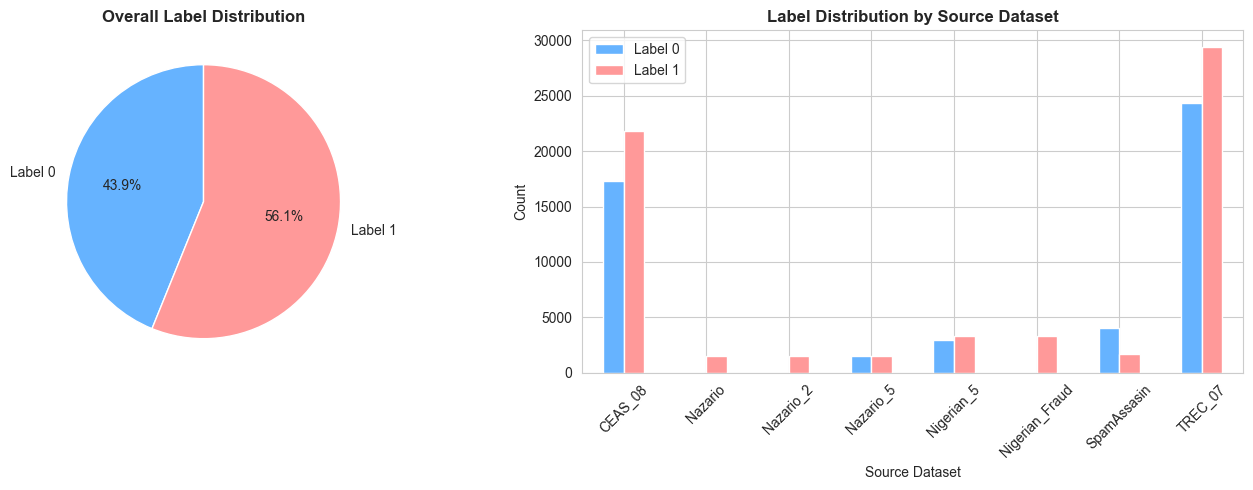

In [9]:
# Overall label distribution
label_counts = email_df['label'].value_counts().sort_index()
label_pct = (email_df['label'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nOverall Label Distribution:")
print(f"Label 0: {label_counts.get(0, 0):,} ({label_pct.get(0, 0)}%)")
print(f"Label 1: {label_counts.get(1, 0):,} ({label_pct.get(1, 0)}%)")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(label_counts, labels=[f'Label {i}' for i in label_counts.index],
            autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Overall Label Distribution', fontsize=12, fontweight='bold')

# Bar chart by source dataset
label_by_source = email_df.groupby(['source_dataset', 'label']).size().unstack(fill_value=0)
label_by_source.plot(kind='bar', ax=axes[1], color=['#66b3ff', '#ff9999'])
axes[1].set_title('Label Distribution by Source Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Dataset')
axes[1].set_ylabel('Count')
axes[1].legend(['Label 0', 'Label 1'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


#### Key Findings:
1. Reasonably balanced: 56.1% phishing (Label 1) vs 43.9% legitimate (Label 0)
2. CEAS_08 & TREC_07 dominate the dataset (largest bars)
3. Nazario variants are almost entirely phishing (Label 1)
4. Nigerian_Fraud is 100% phishing
5. Good mix across sources

2. Duplicates - Remove exact/near duplicates early


Exact Duplicates (all columns): 0 (0.00%)

Duplicates by Key Columns:
  body: 16660 (14.54%)
  subject: 75346 (65.76%)
  subject + body: 16659 (14.54%)
  sender + subject + body: 16658 (14.54%)

----------------------------------------------------------------------
Duplicate Distribution Across Sources:
----------------------------------------------------------------------
source_dataset
Nigerian_5        5592
Nigerian_Fraud    3332
Nazario_5         2804
Nazario           1565
Nazario_2         1565
TREC_07            601
CEAS_08            600
SpamAssasin        600
Name: count, dtype: int64


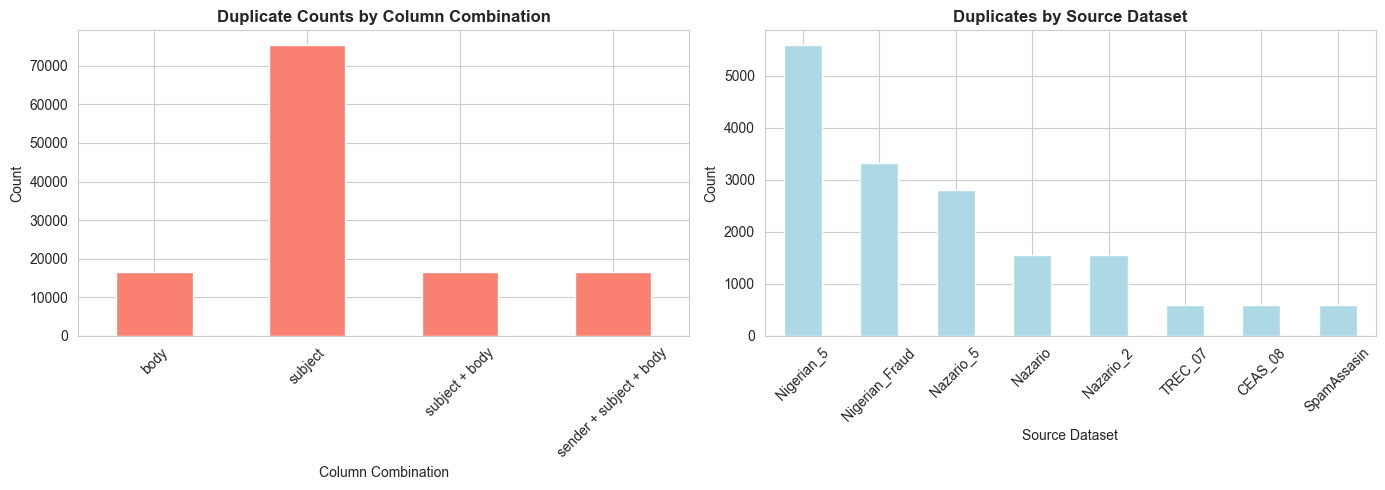


----------------------------------------------------------------------
Sample Duplicate Emails:
----------------------------------------------------------------------


,sender,subject,body,label,source_dataset
43352,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,Nazario_5
427,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,CEAS_08
50648,Bruce D'Ambrosio <ykpbgoxj@cs.orst.edu>,[UAI] CfP: DATE05: Subtrack Real-time Systems,\t\t\t Call for Papers\n\t Subtrack on...,0,Nigerian_5
50668,kmgxpj+iq@gatsby.ucl.ac.uk,[UAI] Three Faculty Positions in CS at Univers...,\t\t UNIVERSITY COLLEGE LONDON\n\n\t\t ...,0,Nigerian_5


In [12]:
# Exact duplicates (all columns)
exact_duplicates = email_df.duplicated().sum()
print(f"\nExact Duplicates (all columns): {exact_duplicates} ({exact_duplicates/len(email_df)*100:.2f}%)")

# Duplicates by key columns
duplicate_analysis = {
    'body': email_df.duplicated(subset=['body'], keep=False).sum(),
    'subject': email_df.duplicated(subset=['subject'], keep=False).sum(),
    'subject + body': email_df.duplicated(subset=['subject', 'body'], keep=False).sum(),
    'sender + subject + body': email_df.duplicated(subset=['sender', 'subject', 'body'], keep=False).sum()
}

print("\nDuplicates by Key Columns:")
for key, count in duplicate_analysis.items():
    print(f"  {key}: {count} ({count/len(email_df)*100:.2f}%)")

# Check if duplicates are in same or different source datasets
print("\n" + "-"*70)
print("Duplicate Distribution Across Sources:")
print("-"*70)

duplicate_mask = email_df.duplicated(subset=['subject', 'body'], keep=False)
duplicate_by_source = email_df[duplicate_mask]['source_dataset'].value_counts()
print(duplicate_by_source)

# Visualize duplicates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duplicate types
dup_data = pd.Series(duplicate_analysis)
dup_data.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Duplicate Counts by Column Combination', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column Combination')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Duplicates by source
duplicate_by_source.plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('Duplicates by Source Dataset', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source Dataset')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Sample duplicate content
print("\n" + "-"*70)
print("Sample Duplicate Emails:")
print("-"*70)
duplicate_bodies = email_df[email_df.duplicated(subset=['body'], keep=False)].sort_values('body')
if len(duplicate_bodies) > 0:
    sample_dup = duplicate_bodies.head(4)[['sender', 'subject', 'body', 'label', 'source_dataset']]
    display(sample_dup)


#### Key Findings:
1. No exact duplicates (0%) - good!
2. 16,660 duplicate bodies (14.54%) - significant!
3. 75,346 duplicate subjects (65.76%) - very high, but subjects can be generic
4. Nigerian datasets have most duplicates (Nigerian_5: 5,592, Nigerian_Fraud: 3,332)

### REMOVING TRUE DUPLICATES (sender + subject + body)
##### Why sender + subject + body is OPTIMAL:
* Truly identical emails - exact same sender, subject, content = zero new information
* Keeps legitimate variations (same content, different senders)
* Preserves diversity while removing actual duplicates
* This is the same email sent multiple times in the dataset

In [20]:
# Store original dimensions
original_rows = len(email_df)
original_cols = email_df.shape[1]

print(f"\nOriginal Dataset Dimensions:")
print(f"  Rows: {original_rows:,}")
print(f"  Columns: {original_cols}")
print(f"  Shape: {original_rows:,} × {original_cols}")

# Remove duplicates based on sender + subject + body
email_df = email_df.drop_duplicates(subset=['sender', 'subject', 'body'], keep='first')

# New dimensions
new_rows = len(email_df)
new_cols = email_df.shape[1]
removed = original_rows - new_rows

print(f"\nAfter Removing Duplicates:")
print(f"  Rows: {new_rows:,}")
print(f"  Columns: {new_cols}")
print(f"  Shape: {new_rows:,} × {new_cols}")

print(f"\nRemoved: {removed:,} duplicate emails ({removed/original_rows*100:.2f}%)")
print(f"Retained: {new_rows:,} unique emails ({new_rows/original_rows*100:.2f}%)")

# Check label distribution after deduplication
print("\n" + "-"*70)
print("Label Distribution After Deduplication:")
print("-"*70)
label_counts_new = email_df['label'].value_counts().sort_index()
for label, count in label_counts_new.items():
    pct = count/new_rows*100
    print(f"  Label {label}: {count:,} ({pct:.2f}%)")

# Memory usage
memory_mb = email_df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory Usage: {memory_mb:.2f} MB")


Original Dataset Dimensions:
  Rows: 114,578
  Columns: 8
  Shape: 114,578 × 8

After Removing Duplicates:
  Rows: 105,077
  Columns: 8
  Shape: 105,077 × 8

Removed: 9,501 duplicate emails (8.29%)
Retained: 105,077 unique emails (91.71%)

----------------------------------------------------------------------
Label Distribution After Deduplication:
----------------------------------------------------------------------
  Label 0: 47,221 (44.94%)
  Label 1: 57,856 (55.06%)

Memory Usage: 258.89 MB
